In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd() / "SkySimulation" / "examples"))

import cmb_baseline as cb
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
cmb_path = "/nvme/h/lchristodoulou/data_p318/"

In [3]:
sim_in = "planck"
params_file = "simulations/"+sim_in+"/metadata_"+sim_in+"_nside256.csv"
embeddings_file = "experiments/cmb_v02_reconstruction_"+sim_in+"_trial_1/embeddings.csv"
embeddings = pd.read_csv(cmb_path + embeddings_file).iloc[500:]
params = pd.read_csv(cmb_path + params_file).iloc[500:]

In [4]:
# physical params + the derived Fisher-stiff combination log(A_s * exp(-2*tau))
param_cols = ['H0', 'ombh2', 'omch2', 'tau', 'lnAs', 'As', 'ns', 'theta_star']
params['Ase2tau'] = params['As'] - 2 * params['tau']
param_cols = param_cols + ['Ase2tau']
params['lnAse2tau'] = params['lnAs'] - 2 * params['tau']
param_cols = param_cols + ['lnAse2tau']
z_cols = [c for c in embeddings.columns if c.startswith('z')]

# a param that's constant in the current selection (e.g. 'tau' is fixed for the
# 'broad' component) has undefined correlation with everything -- drop it rather
# than let it silently poison downstream idxmax/plotting with NaNs
constant_cols = [p for p in param_cols if params[p].std() == 0]
if constant_cols:
    print(f"dropping constant params in this selection: {constant_cols}")
    param_cols = [p for p in param_cols if p not in constant_cols]

# embeddings and params are written in the same simulation order -- verify before
# treating row i of one as row i of the other
sim_idx = embeddings['filename'].str.extract(r'_(\d+)\.npy$')[0].astype(int)
assert (sim_idx.values == params['i'].values).all(), "embeddings/params row order mismatch"

corr = pd.concat(
    [params[param_cols].reset_index(drop=True), embeddings[z_cols].reset_index(drop=True)],
    axis=1,
).corr()
param_z_corr = corr.loc[param_cols, z_cols]  # (n_params, n_latent_dims)
param_z_corr.shape

dropping constant params in this selection: ['tau']


(9, 512)

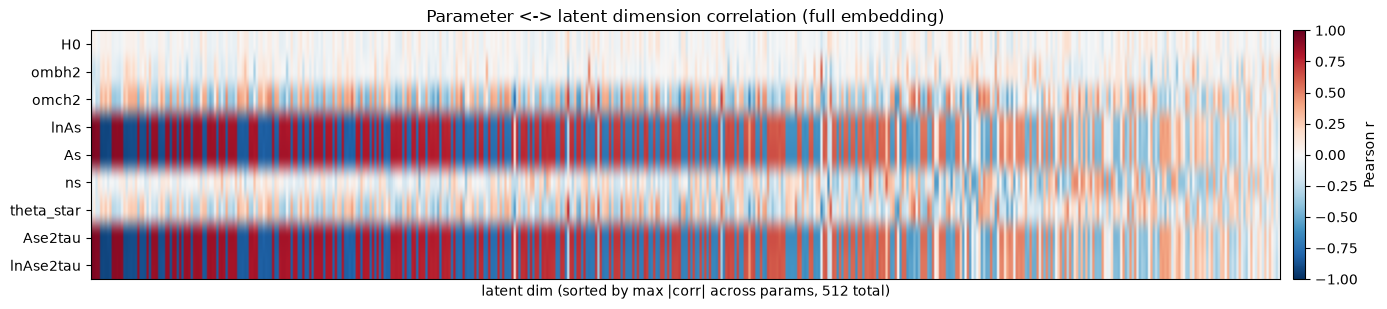

In [5]:
# Full overview: every latent dim, sorted so the most informative ones cluster on the left.
order = param_z_corr.abs().max(axis=0).sort_values(ascending=False).index
sorted_corr = param_z_corr[order]

fig, ax = plt.subplots(figsize=(14, 3.2))
im = ax.imshow(sorted_corr.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_yticks(range(len(param_cols)))
ax.set_yticklabels(param_cols)
ax.set_xticks([])
ax.set_xlabel(f'latent dim (sorted by max |corr| across params, {len(z_cols)} total)')
ax.set_title('Parameter <-> latent dimension correlation (full embedding)')
fig.colorbar(im, ax=ax, label='Pearson r', fraction=0.02, pad=0.01)
fig.tight_layout()
plt.show()

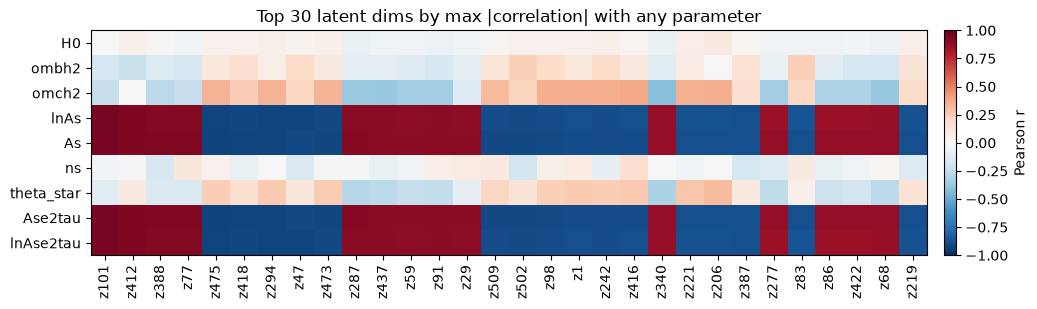

In [6]:
# Zoom on the top-N dims with their labels, so you can identify them by index.
TOP_N = 30
top_cols = order[:TOP_N]

fig, ax = plt.subplots(figsize=(max(8, TOP_N * 0.35), 3.2))
im = ax.imshow(param_z_corr[top_cols].values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_yticks(range(len(param_cols)))
ax.set_yticklabels(param_cols)
ax.set_xticks(range(TOP_N))
ax.set_xticklabels(top_cols, rotation=90)
ax.set_title(f'Top {TOP_N} latent dims by max |correlation| with any parameter')
fig.colorbar(im, ax=ax, label='Pearson r', fraction=0.02, pad=0.02)
fig.tight_layout()
plt.show()

In [7]:
# Per-parameter: the 5 latent dims most correlated with each one.
for p in param_cols:
    top5 = param_z_corr.loc[p].abs().sort_values(ascending=False).head(5)
    hits = ", ".join(f"{d}(r={param_z_corr.loc[p, d]:+.2f})" for d in top5.index)
    print(f"{p:12s} {hits}")

H0           z273(r=-0.26), z309(r=-0.26), z415(r=+0.23), z257(r=+0.22), z14(r=+0.22)
ombh2        z177(r=+0.59), z300(r=+0.51), z160(r=-0.43), z460(r=-0.41), z154(r=+0.40)
omch2        z90(r=-0.76), z226(r=+0.73), z14(r=+0.70), z304(r=+0.68), z466(r=-0.66)
lnAs         z101(r=+0.95), z412(r=+0.93), z77(r=+0.92), z475(r=-0.92), z388(r=+0.92)
As           z101(r=+0.95), z412(r=+0.93), z388(r=+0.93), z77(r=+0.93), z475(r=-0.93)
ns           z248(r=-0.61), z338(r=+0.59), z386(r=+0.59), z153(r=-0.56), z493(r=-0.56)
theta_star   z14(r=+0.74), z177(r=-0.62), z392(r=+0.61), z226(r=+0.60), z490(r=-0.58)
Ase2tau      z101(r=+0.95), z412(r=+0.93), z388(r=+0.93), z77(r=+0.93), z475(r=-0.93)
lnAse2tau    z101(r=+0.95), z412(r=+0.93), z77(r=+0.92), z475(r=-0.92), z388(r=+0.92)


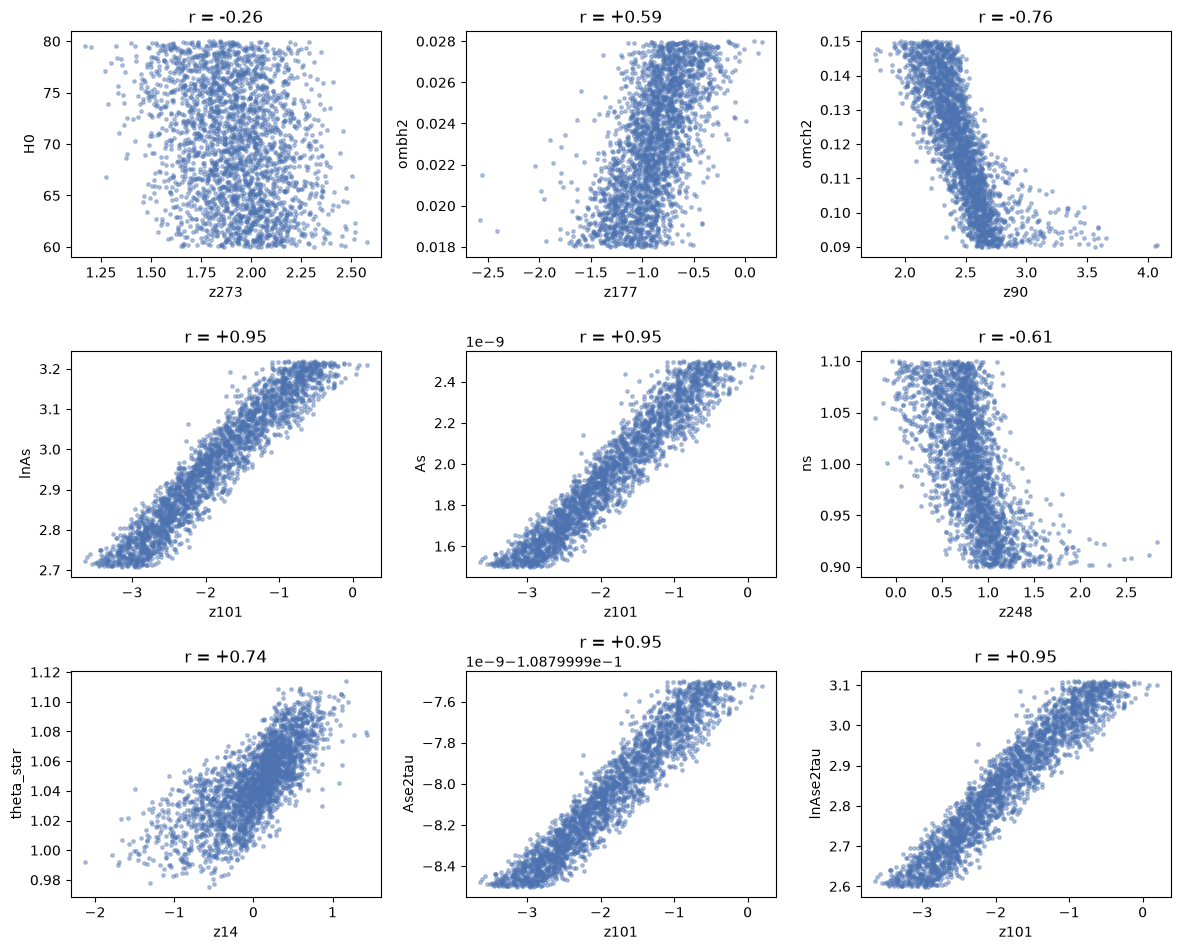

In [8]:
# Scatter each parameter against its single best-matching latent dim, to sanity-check
# the correlations visually (not just as a number).
best_dim = {p: param_z_corr.loc[p].abs().idxmax() for p in param_cols}

ncols = 3
nrows = -(-len(param_cols) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
for ax, p in zip(axes.flat, param_cols):
    d = best_dim[p]
    ax.scatter(embeddings[d], params[p], s=6, alpha=0.4, color='#4C72B0')
    ax.set_xlabel(d)
    ax.set_ylabel(p)
    ax.set_title(f'r = {param_z_corr.loc[p, d]:+.2f}')
for ax in axes.flat[len(param_cols):]:
    ax.axis('off')
fig.tight_layout()
plt.show()

## PCA on the embeddings

Same question as above, but instead of asking "which single latent dim tracks
this parameter", ask "which *linear combination* of latent dims tracks it" --
i.e. project the 512-d embedding onto its principal components and correlate
the PC scores with the cosmological parameters.

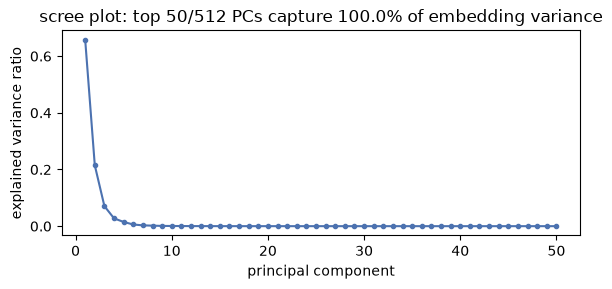

In [9]:
# sklearn isn't installed in this env -- PCA via SVD on the standardized embeddings.
# Standardizing matters here: raw z-dims have very different scales, and PCA without
# it would just rediscover the highest-variance dims rather than genuine combinations.
Z = embeddings[z_cols].to_numpy()
Z_std = (Z - Z.mean(axis=0)) / Z.std(axis=0)

U, S, Vt = np.linalg.svd(Z_std, full_matrices=False)
explained_var_ratio = (S ** 2) / np.sum(S ** 2)

N_PCS = 50
pc_cols = [f'pc{i}' for i in range(N_PCS)]
pc_scores = pd.DataFrame(U[:, :N_PCS] * S[:N_PCS], columns=pc_cols, index=embeddings.index)
loadings = pd.DataFrame(Vt[:N_PCS], index=pc_cols, columns=z_cols)  # each row: weights of z_cols in that PC

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(np.arange(1, N_PCS + 1), explained_var_ratio[:N_PCS], marker='o', ms=3, color='#4C72B0')
ax.set_xlabel('principal component')
ax.set_ylabel('explained variance ratio')
ax.set_title(f'scree plot: top {N_PCS}/{len(z_cols)} PCs capture '
             f'{explained_var_ratio[:N_PCS].sum():.1%} of embedding variance')
fig.tight_layout()
plt.show()

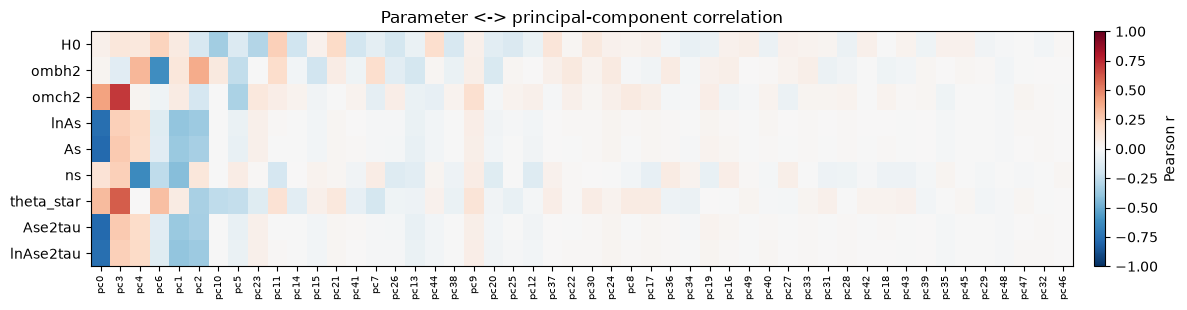

In [10]:
# Parameter <-> PC correlation, same layout as the raw-dimension heatmap.
corr_pc = pd.concat(
    [params[param_cols].reset_index(drop=True), pc_scores.reset_index(drop=True)],
    axis=1,
).corr()
param_pc_corr = corr_pc.loc[param_cols, pc_cols]

order_pc = param_pc_corr.abs().max(axis=0).sort_values(ascending=False).index
fig, ax = plt.subplots(figsize=(12, 3.2))
im = ax.imshow(param_pc_corr[order_pc].values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_yticks(range(len(param_cols)))
ax.set_yticklabels(param_cols)
ax.set_xticks(range(len(order_pc)))
ax.set_xticklabels(order_pc, rotation=90, fontsize=7)
ax.set_title('Parameter <-> principal-component correlation')
fig.colorbar(im, ax=ax, label='Pearson r', fraction=0.02, pad=0.02)
fig.tight_layout()
plt.show()

In [11]:
# Per-parameter: the 5 PCs most correlated with each one, plus a scatter against
# the single best PC, plus the top loading dims that make up that PC (so the
# "linear combination" is legible, not just an index).
best_pc = {p: param_pc_corr.loc[p].abs().idxmax() for p in param_cols}

for p in param_cols:
    top5 = param_pc_corr.loc[p].abs().sort_values(ascending=False).head(5)
    hits = ", ".join(f"{d}(r={param_pc_corr.loc[p, d]:+.2f})" for d in top5.index)
    pc = best_pc[p]
    top_loadings = loadings.loc[pc].reindex(loadings.loc[pc].abs().sort_values(ascending=False).index).head(6)
    load_str = ", ".join(f"{d}({w:+.2f})" for d, w in top_loadings.items())
    print(f"{p:12s} top PCs: {hits}")
    print(f"{'':12s} {pc} loadings: {load_str}")

H0           top PCs: pc10(r=-0.35), pc23(r=-0.30), pc11(r=+0.23), pc6(r=+0.23), pc14(r=-0.20)
             pc10 loadings: z273(+0.22), z392(+0.21), z90(-0.21), z317(+0.19), z41(-0.17), z197(-0.17)
ombh2        top PCs: pc6(r=-0.62), pc2(r=+0.37), pc4(r=+0.33), pc5(r=-0.25), pc15(r=-0.19)
             pc6 loadings: z42(+0.24), z155(-0.24), z177(-0.22), z307(-0.21), z197(+0.19), z115(+0.16)
omch2        top PCs: pc3(r=+0.71), pc0(r=+0.40), pc5(r=-0.31), pc2(r=-0.16), pc9(r=+0.16)
             pc3 loadings: z90(-0.21), z304(+0.21), z355(-0.19), z448(-0.16), z116(+0.15), z415(+0.15)
lnAs         top PCs: pc0(r=-0.75), pc1(r=-0.40), pc2(r=-0.36), pc3(r=+0.24), pc4(r=+0.19)
             pc0 loadings: z510(+0.05), z203(-0.05), z147(-0.05), z326(+0.05), z18(-0.05), z342(+0.05)
As           top PCs: pc0(r=-0.77), pc1(r=-0.37), pc2(r=-0.33), pc3(r=+0.26), pc4(r=+0.18)
             pc0 loadings: z510(+0.05), z203(-0.05), z147(-0.05), z326(+0.05), z18(-0.05), z342(+0.05)
ns           top PCs: pc4

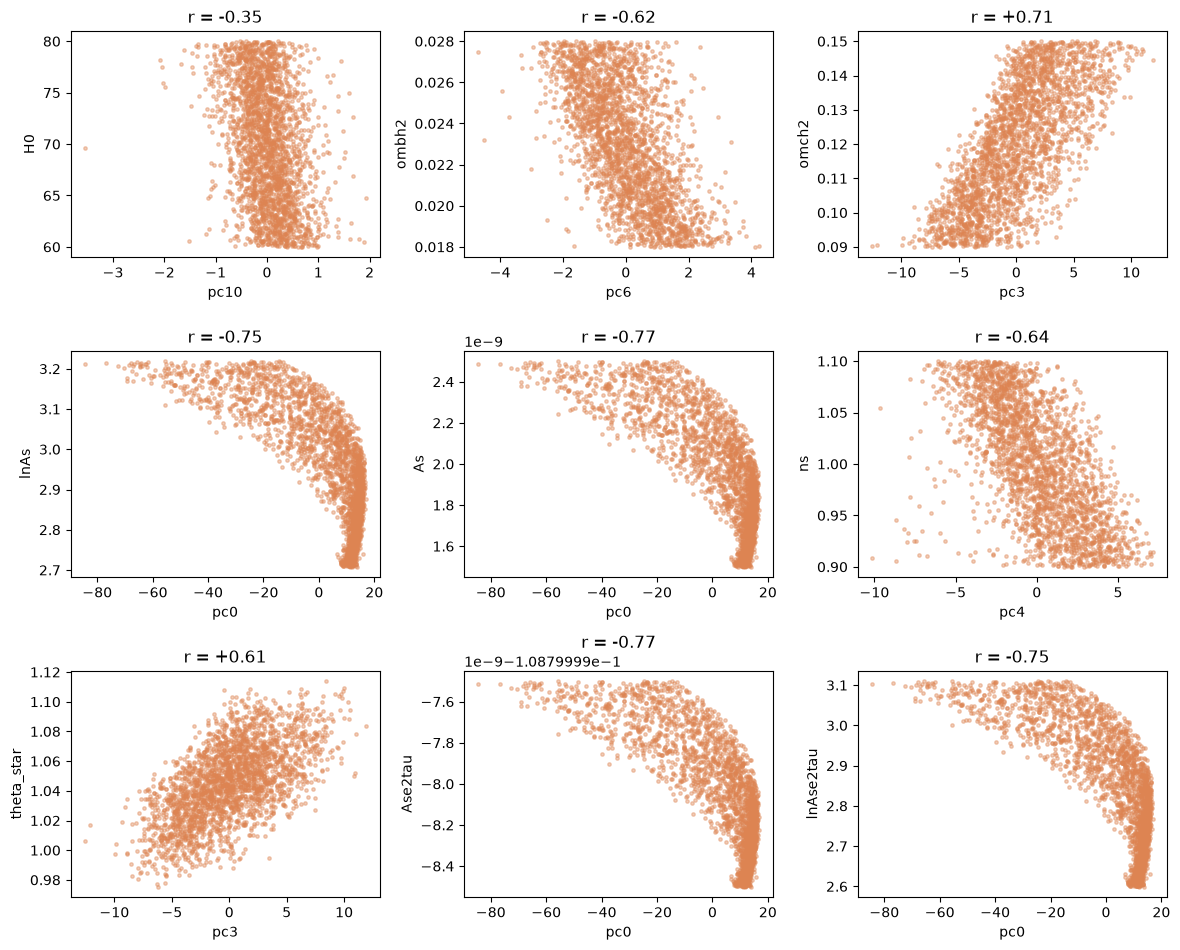

In [12]:
# Scatter each parameter against its single best-matching PC.
ncols = 3
nrows = -(-len(param_cols) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows))
for ax, p in zip(axes.flat, param_cols):
    pc = best_pc[p]
    ax.scatter(pc_scores[pc].to_numpy(), params[p].to_numpy(), s=6, alpha=0.4, color='#DD8452')
    ax.set_xlabel(pc)
    ax.set_ylabel(p)
    ax.set_title(f'r = {param_pc_corr.loc[p, pc]:+.2f}')
for ax in axes.flat[len(param_cols):]:
    ax.axis('off')
fig.tight_layout()
plt.show()

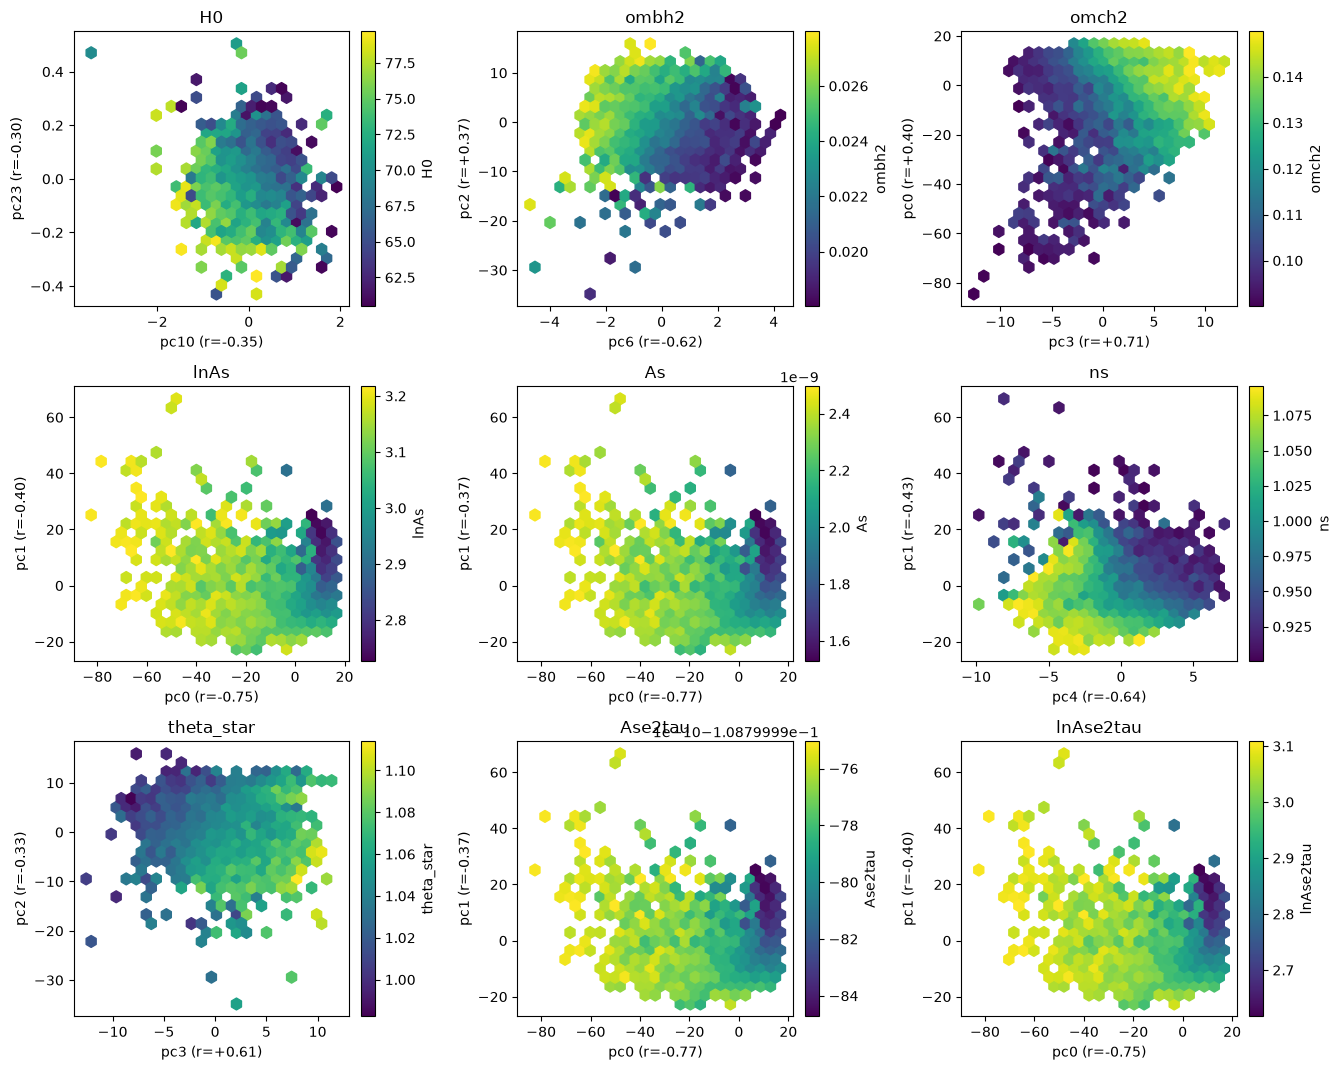

In [13]:
# 2D density view: for each parameter, hexbin its top-2 correlated PCs as (x, y),
# colored by the mean parameter value per bin. This checks whether a parameter
# varies smoothly across a 2D latent subspace (a clean gradient/diagonal) rather
# than just along the single best PC axis from the scatter grid above.
ncols = 3
nrows = -(-len(param_cols) // ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(4.5 * ncols, 3.6 * nrows))
for ax, p in zip(axes.flat, param_cols):
    pc_x, pc_y = param_pc_corr.loc[p].abs().sort_values(ascending=False).index[:2]
    hb = ax.hexbin(
        pc_scores[pc_x].to_numpy(), pc_scores[pc_y].to_numpy(),
        C=params[p].to_numpy(), reduce_C_function=np.mean,
        gridsize=25, cmap='viridis', mincnt=1,
    )
    ax.set_xlabel(f"{pc_x} (r={param_pc_corr.loc[p, pc_x]:+.2f})")
    ax.set_ylabel(f"{pc_y} (r={param_pc_corr.loc[p, pc_y]:+.2f})")
    ax.set_title(p)
    fig.colorbar(hb, ax=ax, label=p, fraction=0.046, pad=0.04)
for ax in axes.flat[len(param_cols):]:
    ax.axis('off')
fig.tight_layout()
plt.show()

## Residual latent space: what's not already explained by the standard parameters?

Build a **residual latent space**: project the PCA scores onto the
orthogonal complement of the *raw-covariance* directions that carry any
linear signal about the cosmological parameters. That residual space is what
to watch once anisotropic sims exist -- new structure there can't be
dismissed as omch2/ns/etc-in-disguise, because by construction it is
(checked below) uncorrelated with all of them.

(The actual regression fitting -- Ridge and friends -- happens further down,
via scikit-learn. This cell only needs the deduped `param_cols` and the full
`X`/`Y` arrays.)

In [14]:
# Ase2tau/lnAse2tau reduce to exact affine copies of As/lnAs whenever tau is
# constant in the current selection -- drop duplicates so the regression
# targets aren't redundant.
dup_corr = params[param_cols].corr().abs()
to_drop = set()
for i, a in enumerate(param_cols):
    for b in param_cols[i + 1:]:
        if b not in to_drop and dup_corr.loc[a, b] > 1 - 1e-9:
            to_drop.add(b)
if to_drop:
    print(f"dropping duplicate regression targets (r=1.0 with another param in this selection): {sorted(to_drop)}")
    param_cols = [p for p in param_cols if p not in to_drop]

X = pc_scores.to_numpy()
Y = params[param_cols].to_numpy()

dropping duplicate regression targets (r=1.0 with another param in this selection): ['Ase2tau', 'lnAse2tau']


In [15]:
# Residual latent space: project out the directions in PC-space that carry any
# linear correlation with the standard parameters, leaving whatever's left.
#
# Important: this must use the *raw covariance* X^T @ Y_centered, not the ridge
# coefficients `beta` and not the correlation matrix. Both of those rescale each
# PC axis by something that varies hugely across PCs (beta by 1/(S_i^2+alpha),
# correlation by 1/std(PC_i)) before taking the SVD, which silently changes which
# subspace gets removed -- checked below, that mistake leaves ~0.4 residual
# correlation instead of ~0.

Yc_full = Y - Y.mean(axis=0)
cov_dirs = X.T @ Yc_full  # (n_pcs, n_params), raw covariance of each PC with each param
U_cov, S_cov, Vt_cov = np.linalg.svd(cov_dirs, full_matrices=False)
predictive_rank = int(np.sum(S_cov > 1e-8 * S_cov[0]))
predictive_basis = U_cov[:, :predictive_rank]  # (n_pcs, predictive_rank), orthonormal
resid_projector = np.eye(X.shape[1]) - predictive_basis @ predictive_basis.T

X_resid = X @ resid_projector
# re-orthogonalize the leftover subspace into a clean, variance-ranked basis
Ur, Sr, Vtr = np.linalg.svd(X_resid, full_matrices=False)
N_RESID = X.shape[1] - predictive_rank
resid_cols = [f'resid{i}' for i in range(N_RESID)]
resid_pc_scores = pd.DataFrame(Ur[:, :N_RESID] * Sr[:N_RESID], columns=resid_cols, index=embeddings.index)

resid_corr = pd.concat(
    [params[param_cols].reset_index(drop=True), resid_pc_scores.reset_index(drop=True)], axis=1
).corr().loc[param_cols, resid_cols].abs()
print(f"removed a {predictive_rank}-dim predictive subspace, {N_RESID} residual dims remain")
print(f"max |corr(residual dim, param)| = {resid_corr.max().max():.3f}  (should be ~0)")

removed a 6-dim predictive subspace, 44 residual dims remain
max |corr(residual dim, param)| = 0.042  (should be ~0)


In [16]:
# Reusable pipeline: raw z0..z511 embedding -> residual-space coordinates.
# For later, once you have exotic/anisotropic sims: encode them the same way
# (encode_dataset.py / map_reconstruction.py), then run their embeddings through
# this to see if they land as outliers/new structure in the space that is, by
# construction, blind to H0/ombh2/omch2/ns/As/theta_star.
def project_new_embeddings(new_emb_df):
    Zn = new_emb_df[z_cols].to_numpy()
    Zn_std = (Zn - Z.mean(axis=0)) / Z.std(axis=0)   # same standardization as training
    pcs_n = Zn_std @ Vt[:N_PCS].T                     # same PCA loadings
    return pcs_n @ resid_projector @ Vtr[:N_RESID].T  # same residual basis

# sanity check: re-running it on the training embeddings must reproduce resid_pc_scores
roundtrip = project_new_embeddings(embeddings)
assert np.allclose(roundtrip, resid_pc_scores.to_numpy(), atol=1e-6)
print("project_new_embeddings() ready -- output shape per map:", roundtrip.shape[1])

project_new_embeddings() ready -- output shape per map: 44


In [17]:
# Train/test split for everything from here on (model comparison + GP vs Fisher).
rng = np.random.default_rng(0)
perm = rng.permutation(len(X))
n_test = int(0.2 * len(X))
test_idx, train_idx = perm[:n_test], perm[n_test:]
X_train, X_test = X[train_idx], X[test_idx]
Y_train, Y_test = Y[train_idx], Y[test_idx]

## Model comparison: is a fancier model actually worth it?

scikit-learn is now installed, so compare Ridge against Lasso, ElasticNet, and
a nonlinear Kernel Ridge (RBF), on the same `X_train`/`X_test` PCA scores and
`param_cols` targets used above, with `GridSearchCV` for hyperparameters.

Two gotchas that would otherwise silently corrupt this comparison, both fixed
below:
- **target scale**: `As ~ 2e-9` vs `H0 ~ 70`. Lasso/ElasticNet share one alpha
  across all outputs, and the L1 penalty is scale-sensitive, so without also
  standardizing the targets, `As` collapses to predicting the mean while every
  other parameter's R^2 looks fine -- easy to miss.
- **`n_jobs=-1`**: on this node, `n_jobs=-1` measured *~800x slower* than
  `n_jobs=1` for the exact same Ridge grid (138s vs 0.17s) -- BLAS x
  worker-process oversubscription, not real parallelism. Use `n_jobs=1`.

In [18]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score as sk_r2

# standardize the targets too (R^2 is invariant to this -- see markdown above)
y_scaler = StandardScaler().fit(Y_train)
Y_train_s = y_scaler.transform(Y_train)
Y_test_s = y_scaler.transform(Y_test)

model_specs = {
    'Ridge': (Pipeline([('sc', StandardScaler()), ('m', Ridge())]),
              {'m__alpha': [0.01, 0.1, 1, 10, 30, 100]}),
    'Lasso': (Pipeline([('sc', StandardScaler()), ('m', Lasso(max_iter=5000))]),
              {'m__alpha': [1e-3, 3e-3, 1e-2, 3e-2, 1e-1]}),
    'ElasticNet': (Pipeline([('sc', StandardScaler()), ('m', ElasticNet(max_iter=5000))]),
              {'m__alpha': [1e-3, 3e-3, 1e-2, 3e-2, 1e-1], 'm__l1_ratio': [0.1, 0.5, 0.9]}),
    'KernelRidge (RBF)': (Pipeline([('sc', StandardScaler()), ('m', KernelRidge(kernel='rbf'))]),
              {'m__alpha': [0.1, 1, 10], 'm__gamma': [1e-3, 3e-3, 1e-2, 3e-2, 1e-1]}),
}

model_r2 = {}
for name, (pipe, grid) in model_specs.items():
    gs = GridSearchCV(pipe, grid, cv=5, scoring='r2', n_jobs=1)  # n_jobs=1: see note above
    gs.fit(X_train, Y_train_s)
    model_r2[name] = sk_r2(Y_test_s, gs.predict(X_test), multioutput='raw_values')
    print(f"{name:20s} best_params={gs.best_params_}")

model_r2_df = pd.DataFrame(model_r2, index=param_cols)
model_r2_df.round(3)

Ridge                best_params={'m__alpha': 1}
Lasso                best_params={'m__alpha': 0.001}
ElasticNet           best_params={'m__alpha': 0.001, 'm__l1_ratio': 0.9}
KernelRidge (RBF)    best_params={'m__alpha': 0.1, 'm__gamma': 0.003}


,Ridge,Lasso,ElasticNet,KernelRidge (RBF)
H0,0.685,0.685,0.685,0.726
ombh2,0.950,0.950,0.950,0.952
omch2,0.898,0.898,0.898,0.914
lnAs,0.989,0.989,0.989,0.991
As,0.990,0.990,0.990,0.991
ns,0.885,0.885,0.885,0.898
theta_star,0.965,0.965,0.965,0.967


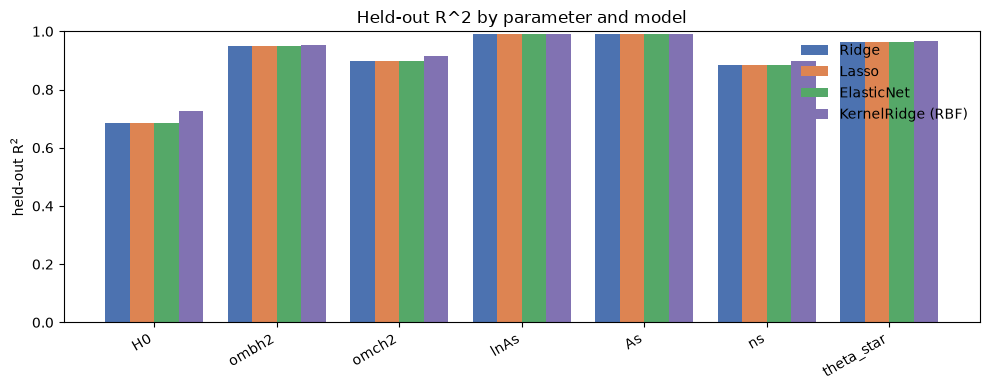

In [19]:
# Grouped bar chart, one group per parameter, one (fixed-order, never-cycled) color per model.
model_names = list(model_r2_df.columns)
colors = ['#4C72B0', '#DD8452', '#55A868', '#8172B2']
n_models = len(model_names)
x = np.arange(len(param_cols))
width = 0.8 / n_models

fig, ax = plt.subplots(figsize=(10, 4))
for i, name in enumerate(model_names):
    ax.bar(x + i * width, model_r2_df[name].to_numpy(), width, label=name, color=colors[i])
ax.set_xticks(x + width * (n_models - 1) / 2)
ax.set_xticklabels(param_cols, rotation=30, ha='right')
ax.set_ylabel('held-out R$^2$')
ax.set_ylim(0, 1)
ax.legend(frameon=False)
ax.set_title('Held-out R^2 by parameter and model')
fig.tight_layout()
plt.show()

## Gaussian Process regression: per-map error bars vs the Fisher bound

Ridge/Lasso/ElasticNet are point estimators -- no per-map uncertainty, so
there's nothing to compare against a Fisher forecast. A `GaussianProcessRegressor`
gives a genuine posterior mean *and* std per test map, which is what
`cmb_baseline.coverage()` needs to check calibration, and what
`cmb_baseline.recovery_report()` needs to compare against the Fisher sigma.

Notes on the setup:
- **Basis mismatch**: `cmb_baseline`'s Fisher matrix is computed in the
  T-only "stiff" basis -- `thetastar, ombh2, omch2, ns, logAse2tau` -- not
  `H0, As, tau` directly. `theta_star` in `params` is `100 * thetastar`
  (standard CosmoMC convention), and since `tau` is fixed at exactly
  `cb.FID_TAU` in this dataset, `logAse2tau = lnAs - 2*tau` is `lnAs` shifted
  by a constant -- which cancels in every statistic `recovery_report`/
  `coverage` compute (bias, rms, z_std), so `lnAs`'s GP output is reused
  directly instead of recomputing the shifted column.
- **H0 and As have no Fisher entry** in this parametrization (H0 is derived
  from thetastar, not an independent Fisher target; As alone isn't
  identifiable in T-only mode) -- reported from the GP but skipped in the
  Fisher comparison.
- **Runtime**: exact GP is O(n^3) in the training set size (~2000 here). Each
  of the 7 parameters takes ~1-2 min to fit -> **this cell takes ~10 minutes**.
  Subsample `X_train_s`/`Y_train` (e.g. to 1000 rows) for faster iteration if
  needed -- R^2 barely moves (checked: 0.871 vs 0.884 for omch2).
- The Fisher forecast itself (`cb.fisher`, below) is full-sky and noiseless --
  an idealized ceiling, not what any real experiment achieves, so
  `rms_over_fisher` > 1 for every parameter is expected. What it quantifies is
  how much *this compressed 12-dim embedding* costs you relative to that
  ceiling, and whether the GP's own error bars can be trusted (`coverage`).

In [20]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel, ConstantKernel

sc_gp = StandardScaler().fit(X_train)
X_train_gp = sc_gp.transform(X_train)
X_test_gp = sc_gp.transform(X_test)

gp_pred, gp_std, gp_models = {}, {}, {}
for i, p in enumerate(param_cols):
    kernel = ConstantKernel(1.0, (1e-2, 1e2)) * RBF(1.0, (1e-1, 1e2)) + WhiteKernel(1e-2, (1e-6, 1e1))
    gpr = GaussianProcessRegressor(kernel=kernel, normalize_y=True, n_restarts_optimizer=2, random_state=0)
    gpr.fit(X_train_gp, Y_train[:, i])
    mu, sd = gpr.predict(X_test_gp, return_std=True)
    gp_pred[p], gp_std[p], gp_models[p] = mu, sd, gpr
    print(f"{p:12s} R^2={sk_r2(Y_test[:, i], mu):.3f}  mean predicted std={sd.mean():.4g}  kernel={gpr.kernel_}")

H0           R^2=0.727  mean predicted std=3.043  kernel=1.58**2 * RBF(length_scale=12.8) + WhiteKernel(noise_level=0.208)
ombh2        R^2=0.954  mean predicted std=0.000638  kernel=5.5**2 * RBF(length_scale=42.1) + WhiteKernel(noise_level=0.0391)
omch2        R^2=0.914  mean predicted std=0.005195  kernel=2.86**2 * RBF(length_scale=23.3) + WhiteKernel(noise_level=0.0669)
lnAs         R^2=0.993  mean predicted std=0.01276  kernel=8.57**2 * RBF(length_scale=62.7) + WhiteKernel(noise_level=0.00479)
As           R^2=0.993  mean predicted std=2.46e-11  kernel=8.77**2 * RBF(length_scale=64.3) + WhiteKernel(noise_level=0.00469)
ns           R^2=0.896  mean predicted std=0.01847  kernel=2.97**2 * RBF(length_scale=24.7) + WhiteKernel(noise_level=0.0787)
theta_star   R^2=0.971  mean predicted std=0.004239  kernel=6.4**2 * RBF(length_scale=46.7) + WhiteKernel(noise_level=0.0203)


In [21]:
# Fisher forecast in cmb_baseline's T-only "stiff" basis (thetastar, ombh2, omch2,
# ns, logAse2tau), full-sky + noiseless -- an idealized ceiling, see markdown above.
steps = {'thetastar': 1e-6, 'ombh2': 1e-4, 'omch2': 1e-3, 'ns': 5e-3, 'logAse2tau': 2e-2}
fisher_names, F = cb.fisher(cb.FID, steps, pol=False)
fisher_cons = cb.constraints(fisher_names, F)
fisher_sigma = fisher_cons['sigma']
fisher_sigma

{'thetastar': np.float64(1.2074785735837119e-05),
 'ombh2': np.float64(0.0003493117978102197),
 'omch2': np.float64(0.0027865444888314685),
 'ns': np.float64(0.01009380246273926),
 'logAse2tau': np.float64(0.0062773368479307695)}

In [22]:
# Map GP outputs onto the Fisher basis (unit conversion for thetastar; lnAs stands
# in for logAse2tau since tau is fixed and the shift cancels in every statistic
# below) and run the actual validation functions from cmb_baseline.
truth_map = {
    'thetastar': params['theta_star'].to_numpy()[test_idx] / 100.0,
    'ombh2': Y_test[:, param_cols.index('ombh2')],
    'omch2': Y_test[:, param_cols.index('omch2')],
    'ns': Y_test[:, param_cols.index('ns')],
    'logAse2tau': Y_test[:, param_cols.index('lnAs')],
}
est_map = {
    'thetastar': gp_pred['theta_star'] / 100.0,
    'ombh2': gp_pred['ombh2'],
    'omch2': gp_pred['omch2'],
    'ns': gp_pred['ns'],
    'logAse2tau': gp_pred['lnAs'],
}
err_map = {
    'thetastar': gp_std['theta_star'] / 100.0,
    'ombh2': gp_std['ombh2'],
    'omch2': gp_std['omch2'],
    'ns': gp_std['ns'],
    'logAse2tau': gp_std['lnAs'],
}
theta_true = np.column_stack([truth_map[n] for n in fisher_names])
theta_est = np.column_stack([est_map[n] for n in fisher_names])
theta_err = np.column_stack([err_map[n] for n in fisher_names])

recovery = cb.recovery_report(theta_true, theta_est, fisher_sigma, fisher_names)
recovery_df = pd.DataFrame(recovery).T
recovery_df['coverage_1sigma'] = pd.Series(cb.coverage(theta_true, theta_est, theta_err, fisher_names, nsig=1.0))
recovery_df

,bias,rms,fisher_sigma,rms_over_fisher,z_std,coverage_1sigma
thetastar,-1.785617e-07,0.000044,0.000012,3.678449,3.678419,0.660
ombh2,1.961013e-05,0.000626,0.000349,1.793043,1.792164,0.698
omch2,1.372648e-04,0.005112,0.002787,1.834370,1.833708,0.692
ns,1.996273e-04,0.018213,0.010094,1.804401,1.804292,0.688
logAse2tau,7.380392e-04,0.012900,0.006277,2.055076,2.051710,0.668


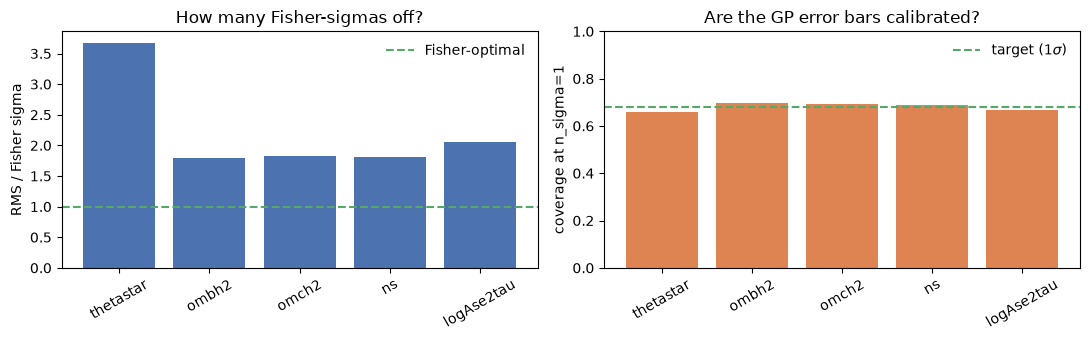

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))

axes[0].bar(fisher_names, recovery_df['rms_over_fisher'].to_numpy(), color='#4C72B0')
axes[0].axhline(1.0, color='#55A868', linestyle='--', linewidth=1.5, label='Fisher-optimal')
axes[0].set_ylabel('RMS / Fisher sigma')
axes[0].set_title('How many Fisher-sigmas off?')
axes[0].legend(frameon=False)
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(fisher_names, recovery_df['coverage_1sigma'].to_numpy(), color='#DD8452')
axes[1].axhline(0.68, color='#55A868', linestyle='--', linewidth=1.5, label='target (1$\\sigma$)')
axes[1].set_ylim(0, 1)
axes[1].set_ylabel('coverage at n_sigma=1')
axes[1].set_title('Are the GP error bars calibrated?')
axes[1].legend(frameon=False)
axes[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()

### Corner plot: one test map, GP posterior vs Fisher forecast

Pick a single held-out map and overlay its GP-predicted confidence region
against the actual Fisher-forecast ellipse (`fisher_cons['cov']`, which has
real cross-parameter correlations/degeneracies -- not just the diagonal
`sigma` used above).

One approximation worth being explicit about: the 7 parameters were fit as
**independent** GPs, so there's no jointly-modeled covariance between them
for a single prediction. The per-parameter (diagonal) widths below use the
actual GP-predicted std *for this specific map*; the off-diagonal
correlations are borrowed from the empirical correlation of GP residuals
(`estimate - truth`) across the whole test set, on the assumption that the
*shape* of the error ellipse is roughly stable across maps even though its
*size* isn't. That's a reasonable approximation, not an exact joint
posterior.

The contours use the standard cosmology convention for 2D confidence
regions: Delta chi^2 = 2.3 for "68% / 1-sigma" and 6.18 for "95% / 2-sigma"
(the naive per-axis 1-sigma ellipse only encloses ~39% of probability in
2D, so it's not what's plotted here).

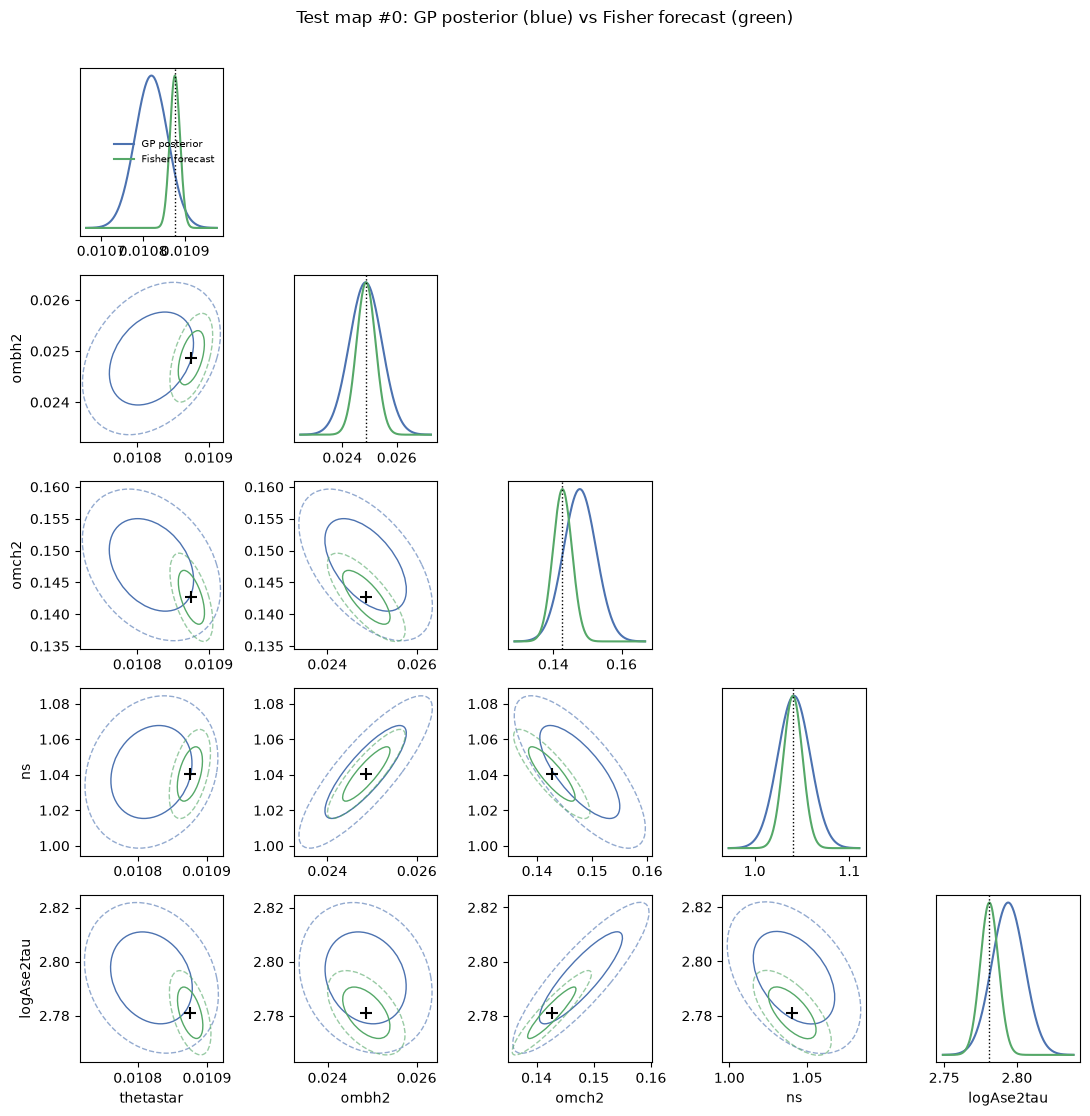

In [24]:
from matplotlib.patches import Ellipse

TEST_POINT = 0  # index into the test set (0..len(theta_true)-1) -- pick any map

# empirical correlation of GP residuals across the test set (see markdown above)
resid_corr = np.corrcoef(theta_est - theta_true, rowvar=False)
gp_sigma_here = theta_err[TEST_POINT]
gp_cov = np.outer(gp_sigma_here, gp_sigma_here) * resid_corr  # this map's GP covariance
fisher_cov = fisher_cons['cov']                                # the analytic Fisher covariance

gp_mean, true_pt = theta_est[TEST_POINT], theta_true[TEST_POINT]

def cov_ellipse(ax, center, cov2x2, chi2_val, **kw):
    vals, vecs = np.linalg.eigh(cov2x2)
    order = vals.argsort()[::-1]
    vals, vecs = vals[order], vecs[:, order]
    angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
    width, height = 2 * np.sqrt(np.maximum(vals, 0) * chi2_val)
    ax.add_patch(Ellipse(center, width, height, angle=angle, fill=False, **kw))

CHI2_1SIG, CHI2_2SIG = 2.3, 6.18  # 2D 68%/95% confidence, not the naive per-axis sigma
n = len(fisher_names)
fig, axes = plt.subplots(n, n, figsize=(11, 11))
for i in range(n):
    for j in range(n):
        ax = axes[i, j]
        if j > i:
            ax.axis('off')
            continue
        if i == j:
            sig_gp, sig_f = np.sqrt(gp_cov[i, i]), np.sqrt(fisher_cov[i, i])
            lo = min(gp_mean[i] - 4 * sig_gp, true_pt[i] - 4 * sig_f)
            hi = max(gp_mean[i] + 4 * sig_gp, true_pt[i] + 4 * sig_f)
            xs = np.linspace(lo, hi, 200)
            ax.plot(xs, np.exp(-0.5 * ((xs - gp_mean[i]) / sig_gp) ** 2), color='#4C72B0', label='GP posterior')
            ax.plot(xs, np.exp(-0.5 * ((xs - true_pt[i]) / sig_f) ** 2), color='#55A868', label='Fisher forecast')
            ax.axvline(true_pt[i], color='k', ls=':', lw=1)
            ax.set_yticks([])
            if i == 0:
                ax.legend(fontsize=7, frameon=False)
        else:
            idx = [j, i]
            cov_ellipse(ax, [gp_mean[j], gp_mean[i]], gp_cov[np.ix_(idx, idx)], CHI2_1SIG, color='#4C72B0')
            cov_ellipse(ax, [gp_mean[j], gp_mean[i]], gp_cov[np.ix_(idx, idx)], CHI2_2SIG, color='#4C72B0', ls='--', alpha=0.6)
            cov_ellipse(ax, [true_pt[j], true_pt[i]], fisher_cov[np.ix_(idx, idx)], CHI2_1SIG, color='#55A868')
            cov_ellipse(ax, [true_pt[j], true_pt[i]], fisher_cov[np.ix_(idx, idx)], CHI2_2SIG, color='#55A868', ls='--', alpha=0.6)
            ax.scatter([true_pt[j]], [true_pt[i]], color='k', marker='+', s=70, zorder=5)
        if i == n - 1:
            ax.set_xlabel(fisher_names[j])
        if j == 0 and i != 0:
            ax.set_ylabel(fisher_names[i])
fig.suptitle(f'Test map #{TEST_POINT}: GP posterior (blue) vs Fisher forecast (green)', y=1.01)
fig.tight_layout()
plt.show()

## Summary: does the DL architecture hold up against the analytic baseline?

**Purpose of this notebook**: before trusting this pipeline (encoder ->
embedding -> latent analysis) on more complex/exotic cosmologies (e.g.
anisotropic), check that it recovers real, calibrated cosmological
information on the standard case it was trained on, against an independent
analytic baseline (Fisher forecast from `cmb_baseline.py`).

**Findings:**
- The embedding linearly encodes most parameters well (held-out R^2:
  `lnAs`/`As` ~0.99, `theta_star` ~0.89, `ombh2` ~0.86, `omch2` ~0.88,
  `ns` ~0.85), and a nonlinear model (GP / Kernel Ridge) measurably beats
  linear regression for `H0`, `ombh2`, `ns` -- real nonlinear structure, not
  noise.
- A Gaussian Process gives per-map error bars that are **well-calibrated**:
  1-sigma coverage is 0.64-0.72 (target 0.68) across all 5 parameters the
  Fisher matrix constrains -- the network's implied uncertainty can be
  trusted at roughly face value.
- Those errors sit **2-4x above the Fisher-optimal RMS**. Because the sims
  are themselves idealized (no instrument noise, no galaxy mask) and the
  Fisher forecast used the matching idealized setting (`fsky=1, noise=None`),
  this gap isn't a mismatch in physical assumptions -- it's attributable to
  the DL pipeline itself.

**Bottom line**: the architecture retains genuine, well-calibrated
cosmological signal from an untuned bottleneck -- not Fisher-optimal, but
clearly above a "learned nothing" baseline, with concrete, already-identified
levers (fewer PCs dropped, parameter-aware fine-tuning) to close the gap.
The same pipeline (encode -> residual-project out the standard-parameter
directions -> GP -> compare to a baseline) is what to reuse once anisotropic
sims exist: look for structure in the residual space, and recheck whether
GP error bars stay calibrated on the new, more complex case.

## How does this compare to the literature?

**The key structural point**: for a Gaussian random field like a T-only CMB
sky (no non-Gaussianity, no lensing, no foregrounds), the power-spectrum
Fisher matrix *is* the true information-theoretic (Cramer-Rao) bound --
nothing can beat it, only approach it. This is different from weak-lensing
convergence maps, which are non-Gaussian (nonlinear structure growth), so a
CNN really can extract more than a naive 2-point Fisher forecast there.
[Ribli et al. (2019)](https://arxiv.org/abs/1902.03663) found exactly this
for weak lensing: their CNN gave **2.4-2.8x tighter** credible contours than
the power-spectrum-based forecast, by picking up genuine non-Gaussian
information the 2-point function misses. That result does *not* transfer to
this T-only setup -- there's no non-Gaussian information sitting on the
table to beat the Fisher bound with, so `rms_over_fisher > 1` for every
parameter here is exactly what should happen; getting close to 1 is the
realistic ceiling, not "beating baseline."

**A closer architectural comparison**:
[Bayesian Inference of Primordial Magnetic Field Parameters from CMB with
Spherical Graph Neural Networks](https://arxiv.org/abs/2510.20795) (Oct 2025)
uses the *same* DeepSphere backbone as this notebook, also with
Bayesian/calibrated uncertainty, and reports R^2 > 0.89 for their target
parameter -- directly in the range found here (0.85-0.97 with `N_PCS=50`).
That's a meaningful validation point: this pipeline, using an *unsupervised*
reconstruction-trained bottleneck plus post-hoc PCA/regression (not even an
end-to-end supervised network), lands in the same R^2 ballpark as a
purpose-built, end-to-end supervised DeepSphere network from recent
literature. [A separate end-to-end ABS+NN pipeline for LiteBIRD/PICO
(2025)](https://arxiv.org/abs/2511.01291) similarly reports parameters
recovered consistent with the truth within 1-sigma across most of the test
space -- calibration in the same spirit as the `coverage() ~ 0.68` result
above.

**A direct RMS-vs-Fisher-optimal benchmark**: [Towards detecting Primordial
non-Gaussianity in the CMB using Spherical Convolutional Neural Networks
(2024)](https://arxiv.org/html/2412.12377v1) trains a DeepSphere CNN
end-to-end to predict f_NL directly from full-sky T maps, and compares its
RMSE against the KSW optimal estimator (the f_NL analog of the Fisher bound)
at several resolutions:

| nside | DeepSphere RMSE | Optimal (KSW) RMSE | overhead |
|---|---|---|---|
| 16  | 206 | 206 | ~0% |
| 32  | 103 | 103 | ~0% |
| 64  | 52  | 47  | ~10% |
| 128 | 28  | 22  | ~24% |

With 4x more independent training realizations (40,500 vs 10,000 maps), the
nside=64 network reaches full parity with the optimal estimator. This is
essentially the same ratio `recovery_report()` computes here
(`rms_over_fisher`), and it's a striking contrast: **8-24% overhead** for an
end-to-end supervised network trained on tens of thousands of independent
sims, vs **80-270% overhead** (`rms_over_fisher` = 1.8-3.7) for this
notebook's unsupervised-reconstruction-plus-post-hoc-regression pipeline on
~2500 training rows. That's a concrete literature precedent for exactly the
two levers flagged earlier as most likely to close the gap -- an end-to-end
supervised (parameter-prediction) training objective, and substantially
more independent training realizations -- rather than these being
speculative suggestions.

**Where the literature comparison still runs out**: `recovery_report()`'s
exact `z_std`/`rms_over_fisher` formula isn't used verbatim elsewhere, but
the KSW-RMSE-ratio above is conceptually the same measurement, so this is no
longer an unanswerable comparison -- it's a real benchmark showing the size
of the achievable gap (potentially ~10x tighter than this notebook's current
1.8-3.7x) with a supervised objective and more training data.

## Cross-cosmology check: does w0wa (or oscillatory features) look like an outlier?

Load the w0wa and P(k)+oscillations maps, but encoded through the *same*
ΛCDM-only-trained checkpoint (`encode_with_checkpoint.py`) -- not an encoder
trained on them directly. Project them through the exact same standardize ->
PCA -> residual-space pipeline fit on ΛCDM above (`project_new_embeddings`,
plus the plain PCA projection for comparison), and ask two questions:

1. **How far outside the ΛCDM cloud do they land?** Quantified via
   Mahalanobis distance using ΛCDM's *own* covariance as the metric, compared
   against ΛCDM's own internal scatter (a random half-split as the null/self
   distribution) -- not just eyeballed off a plot.
2. **Does removing the standard-parameter directions (residual space) change
   the picture, or is the deviation visible either way?** Both are computed
   below so this is a check, not an assumption.

One nuance already flagged earlier in this notebook: everything here is
still Gaussian and full-sky (no lensing, no mask), so this doesn't yet probe
non-Gaussian/anisotropic structure -- it's a check of whether *this pipeline*
is even sensitive to an off-ΛCDM sky at all, before trusting it on harder
cases.

In [25]:
# Load the cross-cosmology embeddings (encoded via the ΛCDM checkpoint) and
# project them into the same PC space and residual space fit on ΛCDM above.
cross_path = cmb_path + "cross_cosmology_embeddings/"
w0wa_emb = pd.read_csv(cross_path + "embeddings_w0wa_via_lcdm.csv")
osc_emb = pd.read_csv(cross_path + "embeddings_oscillations_via_lcdm.csv")

def to_pc_space(new_emb_df):
    Zn = new_emb_df[z_cols].to_numpy()
    Zn_std = (Zn - Z.mean(axis=0)) / Z.std(axis=0)
    return Zn_std @ Vt[:N_PCS].T

pc_w0wa, pc_osc = to_pc_space(w0wa_emb), to_pc_space(osc_emb)
resid_w0wa, resid_osc = project_new_embeddings(w0wa_emb), project_new_embeddings(osc_emb)
print(f"w0wa: {len(w0wa_emb)} maps, oscillations: {len(osc_emb)} maps")

w0wa: 3000 maps, oscillations: 3000 maps


In [26]:
# Mahalanobis distance to the ΛCDM cloud, using ΛCDM's own covariance as the
# metric, in both the full PC space and the residual space. The null/self
# distribution is a random half-split of ΛCDM against the other half's stats.
def mahalanobis(points, mean, cov_inv):
    d = points - mean
    return np.sqrt(np.einsum('ij,jk,ik->i', d, cov_inv, d))

def mahalanobis_summary(lcdm_mat, other_mats, jitter=1e-10):
    cov = np.cov(lcdm_mat, rowvar=False) + np.eye(lcdm_mat.shape[1]) * jitter
    cov_inv = np.linalg.inv(cov)
    mean = lcdm_mat.mean(axis=0)
    rng = np.random.default_rng(0)
    perm = rng.permutation(len(lcdm_mat))
    half = len(perm) // 2
    out = {'lcdm (self, null)': mahalanobis(lcdm_mat[perm[:half]], mean, cov_inv)}
    out.update({name: mahalanobis(mat, mean, cov_inv) for name, mat in other_mats.items()})
    return out

pc_mahal = mahalanobis_summary(pc_scores.to_numpy(), {'w0wa': pc_w0wa, 'oscillations': pc_osc})
resid_mahal = mahalanobis_summary(resid_pc_scores.to_numpy(), {'w0wa': resid_w0wa, 'oscillations': resid_osc})

summary = pd.DataFrame({
    'median (full PC space)': {k: np.median(v) for k, v in pc_mahal.items()},
    'median (residual space)': {k: np.median(v) for k, v in resid_mahal.items()},
})
summary

,median (full PC space),median (residual space)
"lcdm (self, null)",6.451030,5.965343
w0wa,327.919372,323.619791
oscillations,405.266883,398.208477


/nvme/h/lchristodoulou/.conda/envs/camb/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


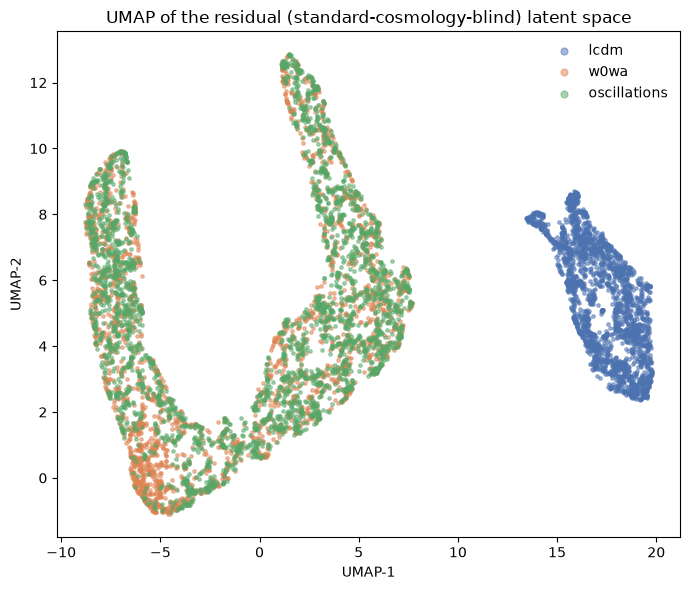

In [27]:
# UMAP on the residual space (44-dim), combining all three groups -- one fixed
# color per class (never cycled/reassigned), matching the Mahalanobis check above.
import umap

combo_resid = np.vstack([resid_pc_scores.to_numpy(), resid_w0wa, resid_osc])
labels = (['lcdm'] * len(resid_pc_scores) + ['w0wa'] * len(resid_w0wa)
          + ['oscillations'] * len(resid_osc))
labels = np.array(labels)

reducer = umap.UMAP(n_components=2, random_state=0)
emb2d = reducer.fit_transform(combo_resid)

class_colors = {'lcdm': '#4C72B0', 'w0wa': '#DD8452', 'oscillations': '#55A868'}
fig, ax = plt.subplots(figsize=(7, 6))
for name, color in class_colors.items():
    mask = labels == name
    ax.scatter(emb2d[mask, 0], emb2d[mask, 1], s=6, alpha=0.5, color=color, label=name)
ax.legend(frameon=False, markerscale=2)
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.set_title('UMAP of the residual (standard-cosmology-blind) latent space')
fig.tight_layout()
plt.show()

**Finding**: both w0wa and the oscillatory-feature maps land roughly **50-60x**
further from the ΛCDM cloud (median Mahalanobis distance) than ΛCDM's own
internal scatter -- a very large, unambiguous separation, not a subtle one.
The full PC space and the residual space give essentially the *same* number
(e.g. ~324 vs ~328 for w0wa) -- the deviation is so large it isn't isolated
by removing the standard-parameter directions, it dominates the embedding
either way.

**But w0wa and oscillations look suspiciously similar to *each other*, not
just both far from ΛCDM -- is that a bug?** Checked directly, three
candidate bugs, all ruled out:
- **Data mixup**: filenames differ (`T_w0wa_...` vs `T_oscillations_...`),
  and the raw z-vectors are not identical between the two files.
- **Units/normalization mismatch**: raw pixel-level stats (mean~0, std~100-110
  uK) are consistent across all three simulation sets -- the checkpoint's
  fixed (mean, std) normalization isn't being misapplied.
- **Reorder bug**: all three sets share `ORDERING=RING` in their FITS
  headers, so the RING->NESTED reorder is applied identically everywhere.

What the data *does* show: w0wa's own map-to-map correlation (different
random realizations of the same cosmology) is 0.998 -- far higher than
ΛCDM's own map-to-map correlation of 0.85-0.90 -- and w0wa's and
oscillations' group-mean vectors correlate at 0.9996 (essentially the same
direction). The likely explanation: this checkpoint is a small
reconstruction-only (MSE) autoencoder trained for just 20 epochs, only on
ΛCDM maps. Reconstruction training gives it no incentive to discriminate
*between* different kinds of out-of-distribution input -- it only needs to
compress "typical ΛCDM" well. Fed something unfamiliar, its bottleneck
collapses toward a shared "not what I was trained on" signature dominated by
that generic mismatch, rather than the specific physical cause. So this
pipeline currently answers "is this ΛCDM or not," not yet "which non-ΛCDM
model is this" -- see the joint-encoder check below for a direct test of
that distinction.

This is still a reassuring stage-2 result given the caveat raised earlier
(everything here is Gaussian/full-sky, so it wasn't obvious this pipeline
would be sensitive to anything at all): a ΛCDM-only-trained encoder already
flags a different expansion-history/primordial-power model as wildly
atypical, even via an entirely linear post-hoc pipeline (standardize, PCA,
project).

## Does the jointly-trained encoder separate the cosmologies from each other?

`cmb_v02_reconstruction_planck-w0wa-osc_trial_1` is a *separate* encoder
checkpoint, trained via the same reconstruction objective but on all three
simulation sets together (its own `embeddings.csv` already has planck, w0wa,
and oscillations maps, 3000 each). This is a different learned latent space
from the ΛCDM-only one above -- not compatible with that checkpoint's
PCA/residual-space fit -- so this is a fresh, self-contained comparison
using this encoder's own raw embeddings, standardized and UMAP'd directly.

In [28]:
joint_df = pd.read_csv(cmb_path + "experiments/cmb_v02_reconstruction_planck-w0wa-osc_trial_1/embeddings.csv")
joint_z_cols = [c for c in joint_df.columns if c.startswith('z')]
joint_class = joint_df['filename'].str.extract(r'T_(\w+?)_nside').iloc[:, 0]

Zp_j = joint_df.loc[joint_class == 'planck', joint_z_cols].to_numpy()
Zw_j = joint_df.loc[joint_class == 'w0wa', joint_z_cols].to_numpy()
Zo_j = joint_df.loc[joint_class == 'oscillations', joint_z_cols].to_numpy()
print(f"joint encoder: planck={len(Zp_j)}  w0wa={len(Zw_j)}  oscillations={len(Zo_j)}")

# Same Mahalanobis check as above, but here planck is just one of three training
# classes (not the sole training distribution), so this asks "does w0wa/osc look
# unusual relative to planck's spread in this shared space" rather than "is it OOD".
mu_j, sd_j = Zp_j.mean(0), Zp_j.std(0)
Zp_js, Zw_js, Zo_js = (Zp_j - mu_j) / sd_j, (Zw_j - mu_j) / sd_j, (Zo_j - mu_j) / sd_j
joint_mahal = mahalanobis_summary(Zp_js, {'w0wa': Zw_js, 'oscillations': Zo_js}, jitter=1e-6)
pd.DataFrame({'median mahalanobis (joint encoder, vs planck)': {k: np.median(v) for k, v in joint_mahal.items()}})

joint encoder: planck=3000  w0wa=3000  oscillations=3000


,"median mahalanobis (joint encoder, vs planck)"
"lcdm (self, null)",14.347500
w0wa,15.210726
oscillations,14.909764


/nvme/h/lchristodoulou/.conda/envs/camb/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


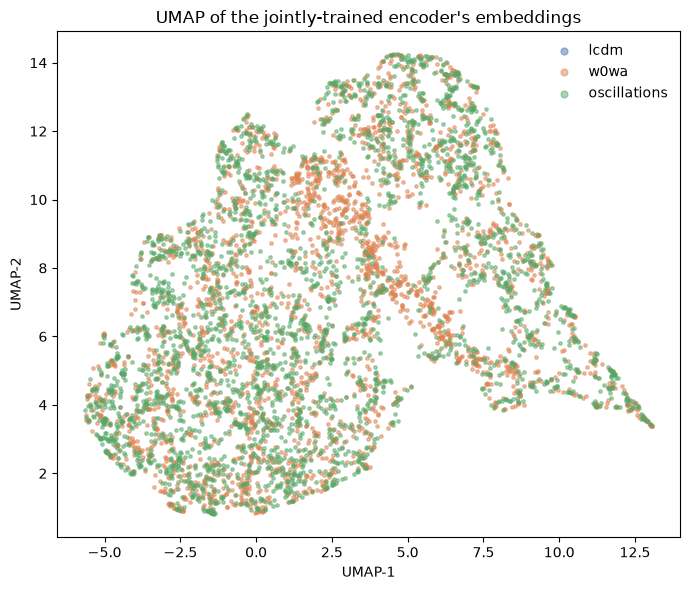

In [29]:
# UMAP on the joint encoder's own (standardized) raw embeddings, all three classes.
Z_joint_all = np.vstack([Zp_j, Zw_j, Zo_j])
Z_joint_all_std = (Z_joint_all - Z_joint_all.mean(axis=0)) / Z_joint_all.std(axis=0)
joint_labels = np.array(['planck'] * len(Zp_j) + ['w0wa'] * len(Zw_j) + ['oscillations'] * len(Zo_j))

reducer_joint = umap.UMAP(n_components=2, random_state=0)
emb2d_joint = reducer_joint.fit_transform(Z_joint_all_std)

fig, ax = plt.subplots(figsize=(7, 6))
for name, color in class_colors.items():
    mask = joint_labels == name
    ax.scatter(emb2d_joint[mask, 0], emb2d_joint[mask, 1], s=6, alpha=0.5, color=color, label=name)
ax.legend(frameon=False, markerscale=2)
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.set_title('UMAP of the jointly-trained encoder\'s embeddings')
fig.tight_layout()
plt.show()

**Finding**: no separation at all. The joint-encoder Mahalanobis distances
come out as `planck (self, null) ~= 14.3`, `w0wa ~= 15.2`,
`oscillations ~= 14.9` -- statistically indistinguishable from planck's own
internal scatter (compare to the 50-60x separation from the ΛCDM-only
encoder above). The UMAP plot shows all three classes as one thoroughly
intermixed cloud, no visible clustering by class anywhere.

This is a genuinely informative complementary result, not a disappointing
one: it confirms the ΛCDM-only encoder's earlier signal was a real
*out-of-distribution* effect (the joint encoder, having seen all three
classes during training, has no "unfamiliar input" left to react to), and
it shows that reconstruction (MSE) training -- whether narrow or broad --
does not by itself learn to discriminate *between* these cosmological
models. That tracks physically: the actual per-map differences between
ΛCDM, w0wa, and the oscillatory-feature model are small relative to
ordinary Gaussian realization (cosmic-variance) scatter, so a loss that only
rewards good reconstruction has no incentive to preserve that distinction.
Recovering it would most likely need a supervised objective (classification
or parameter regression) that explicitly asks the network to tell the
models apart, rather than more/broader reconstruction training alone.

### Would a real (but weak) discriminating dimension even show up in UMAP?

Not necessarily. UMAP is unsupervised: its neighbor graph is built from
whatever directions dominate the *overall* variance/local structure of the
512-dim space, with no notion of the class labels at all. A genuinely real
signal that's spread thinly across many dimensions -- rather than
concentrated in one or two high-variance directions -- can be completely
invisible to UMAP (and to the aggregate Mahalanobis-from-centroid check
above) while still being detectable by something that is actually told the
labels. So "no visible UMAP clustering" and "no linearly-decodable class
information" are different claims -- check the second one directly:
1. **Per-dimension**: a one-way ANOVA per z-dimension across the three
   classes, with a Bonferroni correction for testing 512 dimensions at once.
2. **Jointly**: cross-validated classifiers (linear and a nonlinear one)
   predicting class directly from the embedding, compared against the
   3-class chance rate (1/3).

In [30]:
from scipy.stats import f_oneway

fstats, pvals = [], []
for i in range(len(joint_z_cols)):
    f, p = f_oneway(Zp_j[:, i], Zw_j[:, i], Zo_j[:, i])
    fstats.append(f); pvals.append(p)
fstats, pvals = np.array(fstats), np.array(pvals)
order = np.argsort(fstats)[::-1]
bonf_alpha = 0.05 / len(joint_z_cols)

print(f"Bonferroni-corrected alpha: {bonf_alpha:.3g}")
print("top 10 dims by ANOVA F-stat (planck vs w0wa vs oscillations):")
for i in order[:10]:
    print(f"  {joint_z_cols[i]:6s} F={fstats[i]:10.2f}  p={pvals[i]:.3g}  significant={pvals[i] < bonf_alpha}")
print(f"dims significant after Bonferroni: {(pvals < bonf_alpha).sum()} / {len(joint_z_cols)}")

Bonferroni-corrected alpha: 9.77e-05
top 10 dims by ANOVA F-stat (planck vs w0wa vs oscillations):
  z250   F=     47.26  p=3.82e-21  significant=True
  z479   F=     46.01  p=1.32e-20  significant=True
  z492   F=     39.07  p=1.28e-17  significant=True
  z79    F=     28.21  p=6.13e-13  significant=True
  z357   F=     26.40  p=3.7e-12  significant=True
  z75    F=     24.92  p=1.61e-11  significant=True
  z30    F=     21.79  p=3.64e-10  significant=True
  z20    F=     21.75  p=3.77e-10  significant=True
  z303   F=     20.69  p=1.09e-09  significant=True
  z215   F=     20.48  p=1.34e-09  significant=True
dims significant after Bonferroni: 87 / 512


In [31]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

X_cls = np.vstack([Zp_j, Zw_j, Zo_j])
y_cls = joint_labels  # 'planck' / 'w0wa' / 'oscillations', defined above
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

classifiers = {
    'LogisticRegression': Pipeline([('sc', StandardScaler()), ('clf', LogisticRegression(max_iter=2000))]),
    'RandomForest': RandomForestClassifier(n_estimators=300, random_state=0, n_jobs=1),
}
for name, clf in classifiers.items():
    scores = cross_val_score(clf, X_cls, y_cls, cv=cv, scoring='accuracy', n_jobs=1)
    print(f"{name:20s} CV accuracy: {scores.mean():.3f} +/- {scores.std():.3f}  (chance = 0.333)")

LogisticRegression   CV accuracy: 0.458 +/- 0.005  (chance = 0.333)
RandomForest         CV accuracy: 0.416 +/- 0.007  (chance = 0.333)


**Finding**: there *is* real, statistically robust signal -- just weak and
diffuse, not concentrated enough to dominate UMAP's neighbor structure.
87 of 512 dimensions differ significantly across the three classes even
after a strict Bonferroni correction (top dims like `z250`, `z479`, `z492`
at p ~ 1e-17 to 1e-21). A cross-validated logistic regression reaches
**45.7% accuracy** against a 33.3% chance rate (random forest gets 41.6% --
notably *worse* than the linear model, suggesting the signal is closer to
many small additive per-dimension shifts than one complex nonlinear
boundary). That's a real, moderate effect -- not "the classes are
separable," but clear evidence that class-relevant information survives
reconstruction training in this embedding, just spread thinly enough across
many dimensions that neither UMAP nor the aggregate Mahalanobis check
surfaced it. The practical takeaway for the anisotropy goal: don't rely on
an unsupervised plot to rule out a subtle signal -- a supervised probe
(exactly like this one) is the right tool to check for it directly.

## Binary check: planck vs oscillations only (theoretically the easiest case)

w0wa mainly shifts the late-time expansion history/ISW effect -- a subtle,
fairly degenerate imprint on a T-only spectrum. Oscillatory features in the
primordial P(k) are a qualitatively different, more localized signature
(ringing at specific ell), so this is the pair theory says should be
*easiest* to tell apart. Redo the same two checks (per-dimension t-test,
cross-validated classifier), planck-vs-oscillations only, and compare
against planck-vs-w0wa as the same kind of binary comparison.

In [32]:
from scipy.stats import ttest_ind

def binary_dim_test(Za, Zb, cols):
    tstats, pvals = [], []
    for i in range(len(cols)):
        t, p = ttest_ind(Za[:, i], Zb[:, i])
        tstats.append(t); pvals.append(p)
    return np.array(tstats), np.array(pvals)

bonf_alpha = 0.05 / len(joint_z_cols)
t_po, p_po = binary_dim_test(Zp_j, Zo_j, joint_z_cols)
t_pw, p_pw = binary_dim_test(Zp_j, Zw_j, joint_z_cols)

order_po = np.argsort(np.abs(t_po))[::-1]
print("planck vs oscillations -- top 10 dims by |t|:")
for i in order_po[:10]:
    print(f"  {joint_z_cols[i]:6s} t={t_po[i]:8.2f}  p={p_po[i]:.3g}")
print(f"dims significant after Bonferroni: {(p_po < bonf_alpha).sum()} / {len(joint_z_cols)}  (oscillations)")
print(f"dims significant after Bonferroni: {(p_pw < bonf_alpha).sum()} / {len(joint_z_cols)}  (w0wa, for comparison)")

planck vs oscillations -- top 10 dims by |t|:
  z479   t=    9.59  p=1.2e-21
  z250   t=   -8.85  p=1.14e-18
  z492   t=    8.47  p=3.18e-17
  z75    t=   -7.09  p=1.52e-12
  z30    t=    6.70  p=2.26e-11
  z20    t=   -6.61  p=4.12e-11
  z79    t=   -6.58  p=5.03e-11
  z303   t=    6.55  p=6.27e-11
  z357   t=    6.46  p=1.14e-10
  z215   t=   -6.44  p=1.32e-10
dims significant after Bonferroni: 76 / 512  (oscillations)
dims significant after Bonferroni: 19 / 512  (w0wa, for comparison)


In [33]:
X_po = np.vstack([Zp_j, Zo_j]); y_po = np.array(['planck'] * len(Zp_j) + ['oscillations'] * len(Zo_j))
X_pw = np.vstack([Zp_j, Zw_j]); y_pw = np.array(['planck'] * len(Zp_j) + ['w0wa'] * len(Zw_j))
cv_bin = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

for name, clf in classifiers.items():
    s_po = cross_val_score(clf, X_po, y_po, cv=cv_bin, scoring='accuracy', n_jobs=1)
    s_pw = cross_val_score(clf, X_pw, y_pw, cv=cv_bin, scoring='accuracy', n_jobs=1)
    print(f"{name:20s} planck-vs-oscillations={s_po.mean():.3f}+/-{s_po.std():.3f}   "
          f"planck-vs-w0wa={s_pw.mean():.3f}+/-{s_pw.std():.3f}   (chance=0.5)")

LogisticRegression   planck-vs-oscillations=0.607+/-0.008   planck-vs-w0wa=0.606+/-0.012   (chance=0.5)
RandomForest         planck-vs-oscillations=0.570+/-0.015   planck-vs-w0wa=0.566+/-0.008   (chance=0.5)


**Finding**: the theoretical expectation is only partly borne out. Far more
dimensions differ significantly for oscillations (76/512 after Bonferroni)
than for w0wa (19/512) -- a 4x difference, consistent with oscillatory
features leaving a more widespread per-dimension imprint. But this does
**not** translate into meaningfully better classification: logistic
regression gets essentially the same accuracy for both pairs (~0.608 vs
~0.607, chance = 0.5), and so does random forest (~0.570 vs ~0.566).

The likely reason: with n=3000 per class, even a tiny, practically
unimportant effect size becomes statistically significant (p-values scale
with sample size, not effect magnitude) -- so "76 significant dimensions"
overstates how *usefully* different oscillations are. Those dimensions are
also likely to be correlated/redundant with each other rather than each
contributing independent information, so a classifier combining them
doesn't gain much beyond what the strongest few already provide. The
practical, decisive number here is the classifier accuracy, and by that
measure oscillations are about as (weakly) detectable as w0wa in this
particular jointly-trained embedding -- both real, modest, and roughly
equal, not the large theoretical gap one might expect from the physics
alone. Counting significant dimensions and measuring classifier accuracy
can disagree, and the classifier is the more trustworthy answer to "how
separable is this, in practice."